In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [6]:
np.random.seed(33550336)
rng = np.random.default_rng()

In [19]:
N = 1000000

In [20]:
xc = rng.uniform(0, 1, size = N)
yc = rng.uniform(0, 1, size = N)
p2d = np.column_stack((xc, yc))

In [21]:
M = 0
for i in range(N):
    if xc[i] ** 2 + yc[i] ** 2 <= 1:
        M += 1

In [22]:
4 * M/N

3.141012

In [26]:
acc = []
tota = 0
while len(acc) < 1000:
    tota += 1
    x = np.random.uniform(-5, 5)
    u = np.random.uniform(0, 1)
    prob = sp.stats.norm.pdf(x, 0, 1) / 0.4
    if u <= prob:
        acc.append(x)

In [28]:
tota

4054

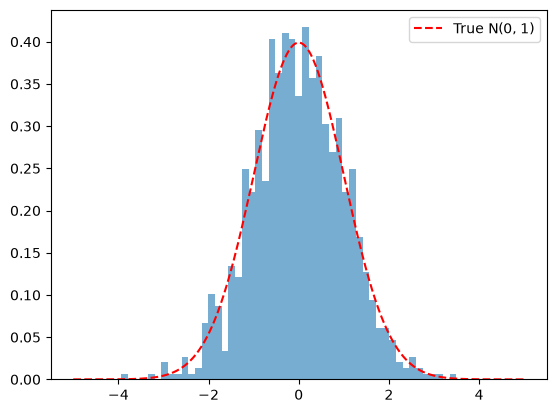

In [29]:
plt.hist(acc, bins = 50, density = True, alpha = 0.6)
xr = np.linspace(-5, 5, 1000)
plt.plot(xr, sp.stats.norm.pdf(xr, 0, 1), 'r--', label = 'True N(0, 1)')
plt.legend()
plt.show()



In [35]:
def lop(x):
    return - x[0] ** 2/2 - ((x[1] - x[0] ** 2) ** 2)/2

In [58]:
current = np.array([1, 1])
sig = 2.0
T = 10000
sam = np.empty((T, 2))
acc = 0

In [59]:
for _ in range(T):
    prop = current + np.random.normal(0, sig, size = 2)
    lalppha = lop(prop) - lop(current)
    if lalppha >= 0:
        current = prop
        acc += 1
    elif np.log(np.random.uniform(0, 1)) <= lalppha:
        current = prop
        acc += 1
    sam[_] = current

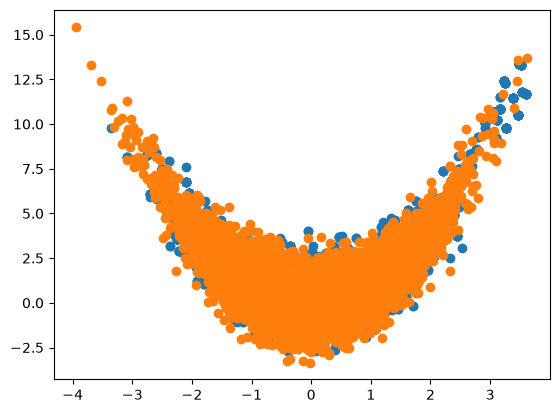

In [64]:
sb = sam[2000:]
xe = np.random.normal(0, 1, size = 8000)
ye = np.random.normal(xe ** 2, 1)
ex = np.column_stack([xe, ye])
plt.scatter(sb[:, 0], sb[:, 1])
plt.scatter(ex[:, 0], ex[:, 1])

In [61]:
acc/T

0.2481